## 1. Load the dataset

In [1]:
import pandas as pd

DATA_FILE = "pina-indians-cleaned-v2.csv"

df = pd.read_csv(DATA_FILE)
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


## 2. Total number of rows

In [2]:
total_rows, total_columns = df.shape
print(f"Total rows:    {total_rows}")
print(f"Total columns: {total_columns}")

Total rows:    729
Total columns: 9


## 3. Column types & completeness

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 729 entries, 0 to 728
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               729 non-null    int64  
 1   Glucose                   729 non-null    int64  
 2   BloodPressure             729 non-null    int64  
 3   SkinThickness             729 non-null    int64  
 4   Insulin                   729 non-null    int64  
 5   BMI                       729 non-null    float64
 6   DiabetesPedigreeFunction  729 non-null    float64
 7   Age                       729 non-null    int64  
 8   Outcome                   729 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 51.4 KB


## 4. Summary statistics

In [4]:
print(df.describe().round(2))

       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       729.00   729.00         729.00         729.00   729.00  729.00   
mean          3.86   121.05          72.37          21.50    83.95   32.47   
std           3.36    32.26          12.38          15.71   116.80    6.89   
min           0.00     0.00          24.00           0.00     0.00   18.20   
25%           1.00    99.00          64.00           0.00     0.00   27.50   
50%           3.00   117.00          72.00          24.00    46.00   32.40   
75%           6.00   141.00          80.00          33.00   130.00   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    729.00  729.00   729.00  
mean                       0.47   33.32     0.34  
std                        0.33   11.75     0.48  
min                        0.08   21.00     0.00  
25%                        0.24   24.00   

## 5. The Summaries


As requested in rubric point 5

* **Summary 1 — counts by category.** How many rows (people) fall in each BMI band, split by
  diabetes outcome. How many in this case is the same as 'frequency'.
* **Summary 2 — averages and medians by group.** The typical Glucose, BMI, Age and
  Insulin for each outcome group.  This is a *central tendency* - it shows where the data is 'clustering' or where there are a lot of data points.
  Lots of data points means something is happening there, there's action...

A count answers "how many", an average answers "how much" - two genuinely different
questions about the same rows. Two count tables would not count as two different
summaries.

There is **no time or date column** in this dataset (`Age` is a patient attribute, not a
time index), so a "changes over time" summary is not possible here.

Both use `pina-indians-cleaned-v2.csv`, produced by `clean_pima.py` then
`clean_pima_v2.py`: 729 rows.

In [5]:
# Summary 1: counts by category (a frequency view). Expects the cleaned csv to sit
# next to this notebook, in the same folder.
df_v2 = pd.read_csv("pina-indians-cleaned-v2.csv")
print(f"cleaned dataset: {len(df_v2)} rows   (original: {len(df)} rows)")

print("\nPatients by outcome (0 = no diabetes, 1 = diabetes):")
print(df_v2["Outcome"].value_counts().sort_index().to_string())

# Clinical BMI bands, using the standard breakpoints.
bmi_bands = [0, 18.5, 25, 30, 35, 40, float("inf")]
bmi_labels = ["<18.5 underweight", "18.5-25 normal", "25-30 overweight",
              "30-35 obese I", "35-40 obese II", "40+ obese III"]
df_v2["BMI band"] = pd.cut(df_v2["BMI"], bins=bmi_bands, labels=bmi_labels, right=False)

counts = pd.crosstab(df_v2["BMI band"], df_v2["Outcome"], margins=True, margins_name="Total")
counts.columns = ["No diabetes (0)", "Diabetes (1)", "Total"]
counts["% with diabetes"] = (counts["Diabetes (1)"] / counts["Total"] * 100).round(1)
print(counts)

cleaned dataset: 729 rows   (original: 729 rows)

Patients by outcome (0 = no diabetes, 1 = diabetes):
Outcome
0    478
1    251
                   No diabetes (0)  Diabetes (1)  Total  % with diabetes
BMI band                                                                
<18.5 underweight                4             0      4              0.0
18.5-25 normal                  90             7     97              7.2
25-30 overweight               134            38    172             22.1
30-35 obese I                  122            95    217             43.8
35-40 obese II                  85            61    146             41.8
40+ obese III                   43            50     93             53.8
Total                          478           251    729             34.4


In [6]:
# Summary 2: averages and medians by group (a central-tendency view).
# Widen pandas' text display so this 10-column table prints in one block instead of
# wrapping, and stop it abbreviating the middle columns with "...". Both settings are
# needed: width alone still hides a column.
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

measures = ["Glucose", "BMI", "Age", "Insulin", "Pregnancies"]
print(df_v2.groupby("Outcome")[measures].agg(["mean", "median"]).round(1))

        Glucose          BMI          Age        Insulin        Pregnancies       
           mean median  mean median  mean median    mean median        mean median
Outcome                                                                           
0         110.3  107.0  31.0   30.4  31.2   27.0    71.8   45.0         3.3    2.0
1         141.5  140.0  35.4   34.3  37.4   36.0   107.1   58.0         4.9    5.0


### Reading the two summaries together

* The diabetes rate rises with BMI - it is printed in the last column above.
* Diabetic patients average far higher **Glucose** (141.5 vs 110.3) than non-diabetic
  patients; the gap for **BMI** is much smaller (35.4 vs 31.0). Glucose separates the two groups far more sharply than BMI does.
* **Insulin's mean and median disagree sharply** - for the non-diabetic group the mean is
  71.8 but the median is 45.0. That is right-skew: a few very high values drag the mean
  upward, so for Insulin the **median** is the more trustworthy summary. Glucose is
  nearly symmetric (mean 110.3, median 107.0), so its mean is fine. This is exactly why
  the brief says "averages **or** medians" rather than assuming one is always best.

## 6. Simple linear regression: Glucose → Outcome

A *simple* regression uses a single predictor. Here the predictor is **Glucose** and the
target is **Outcome**, the final column.

`LinearRegression` fits the straight line that comes closest to the points. Because
`Outcome` is binary (0 = no diabetes, 1 = diabetes), this is a **linear probability
model**: the slope is the change in the predicted probability of diabetes per 1 mg/dL of
glucose. That is easy to read, but nothing stops the line predicting below 0 or above 1,
so logistic regression is the technically correct tool for a binary target.

Note: 5 rows record `Glucose = 0`, this dataset's placeholder for a missing measurement
rather than a real reading. They are kept in here for simplicity - excluding them raises
R^2 from 0.218 to 0.245.

In [7]:
from scipy import stats
from sklearn.linear_model import LinearRegression

# scikit-learn expects a 2-D X, so the column is selected with double brackets.
X = df[["Glucose"]]
y = df["Outcome"]

glucose_model = LinearRegression().fit(X, y)

print(f"Rows used              : {len(df)}")
print(f"Slope (per mg/dL)      : {glucose_model.coef_[0]:.5f}")
print(f"Intercept              : {glucose_model.intercept_:.3f}")
print(f"R^2                    : {glucose_model.score(X, y):.3f}")

# Pearson's r for the same pair. With a single predictor R^2 IS r^2, so r is just the
# square root of the R^2 above, carrying the sign of the slope.
r, p_value = stats.pearsonr(df["Glucose"], df["Outcome"])
print(f"Pearson r              : {r:+.3f}  (r^2 = {r**2:.3f}, matching R^2)")
print(f"p-value                : {p_value:.2e}")

pred = glucose_model.predict(X)
print(f"Predictions outside 0-1: {int(((pred < 0) | (pred > 1)).sum())} of {len(pred)}")

Rows used              : 729
Slope (per mg/dL)      : 0.00677
Intercept              : -0.475
R^2                    : 0.211
Pearson r              : +0.459  (r^2 = 0.211, matching R^2)
p-value                : 2.60e-39
Predictions outside 0-1: 16 of 729


In [8]:
# What the fitted line predicts at a few glucose readings. Predictions are passed as a
# DataFrame rather than a bare list so scikit-learn does not warn about feature names.
for value in (80, 100, 140, 180):
    chance = glucose_model.predict(pd.DataFrame({"Glucose": [value]}))[0]
    print(f"Glucose {value:>3} mg/dL -> predicted probability of diabetes {chance:.3f}")

Glucose  80 mg/dL -> predicted probability of diabetes 0.066
Glucose 100 mg/dL -> predicted probability of diabetes 0.202
Glucose 140 mg/dL -> predicted probability of diabetes 0.473
Glucose 180 mg/dL -> predicted probability of diabetes 0.743


### The relationship, plotted

The bars group patients by glucose band and show the share in each band who tested
positive. The line is the same fitted regression as above, evaluated at a representative
glucose value in each band. The two track each other closely - the "glucose hypothesis"
made visible: the higher the glucose reading, the higher the chance of diabetes.

wrote glucose_vs_outcome.png

              patients  observed rate  fitted
Glucose band                                 
<100               186          0.086   0.134
100-120            199          0.256   0.270
120-140            154          0.364   0.405
140-160             91          0.516   0.540
160-180             55          0.800   0.676
180+                44          0.841   0.811


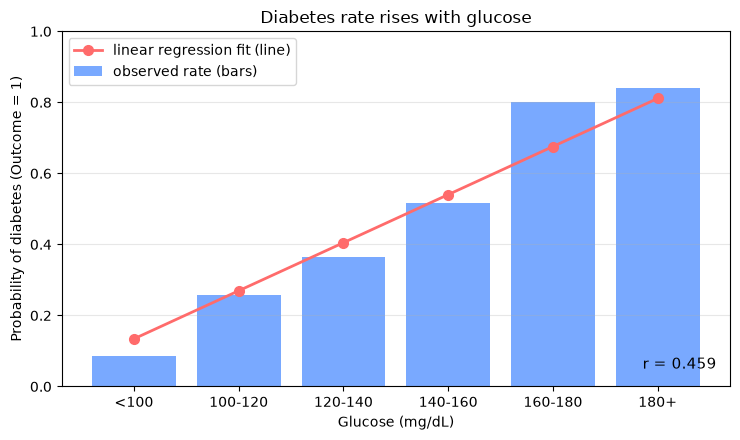

In [9]:
import sys

import matplotlib

# In a notebook an inline backend is already active, so the figure displays on its own.
# A plain script has no display to render into, so use Agg - otherwise the default
# backend waits for a window that never appears and the script hangs.
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt

# Roughly the clinical breakpoints: under 100 is normal fasting glucose, 100-125 is
# pre-diabetic, 126 and above is the diabetic range.
glucose_bands = [0, 100, 120, 140, 160, 180, float("inf")]
glucose_labels = ["<100", "100-120", "120-140", "140-160", "160-180", "180+"]
band_midpoints = [90, 110, 130, 150, 170, 190]

banded = df.copy()
banded["Glucose band"] = pd.cut(banded["Glucose"], bins=glucose_bands,
                                labels=glucose_labels, right=False)

observed = banded.groupby("Glucose band", observed=True)["Outcome"].mean()
sizes = banded.groupby("Glucose band", observed=True)["Outcome"].size()
fitted = glucose_model.predict(pd.DataFrame({"Glucose": band_midpoints}))

fig, ax = plt.subplots(figsize=(7.5, 4.5))

ax.bar(range(len(observed)), observed.values, color="#4c8dff", alpha=0.75,
       label="observed rate (bars)")
ax.plot(range(len(observed)), fitted, "o-", color="#ff6b6b", lw=2, ms=7,
        label="linear regression fit (line)")

# Both series are probabilities, so they share one 0-1 scale.
ax.set_xticks(range(len(observed)))
ax.set_xticklabels(observed.index)
ax.set_xlabel("Glucose (mg/dL)")
ax.set_ylabel("Probability of diabetes (Outcome = 1)")
ax.set_title("Diabetes rate rises with glucose")
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)

# Annotate the correlation so the figure stands on its own. Computed here from the
# data rather than hard-coded, so it cannot go stale. For a single predictor r is
# the square root of R^2, carrying the slope's sign.
r_value = df["Glucose"].corr(df["Outcome"])
ax.text(0.98, 0.04, f"r = {r_value:.3f}", transform=ax.transAxes,
        ha="right", va="bottom", fontsize=11)
fig.tight_layout()

# Saved so the plain script still produces something you can open.
fig.savefig("glucose_vs_outcome.png", dpi=110, bbox_inches="tight")
print("wrote glucose_vs_outcome.png")

print()
print(pd.DataFrame({
    "patients": sizes,
    "observed rate": observed.round(3),
    "fitted": fitted.round(3),
}).to_string())